In [51]:
import pandas as pd

df = pd.read_csv("/content/credit_card.csv")

print(df.columns)
print(df.head())

Index(['CUST_ID', 'BALANCE', 'PURCHASES', 'INSTALLMENTS_PURCHASES',
       'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS',
       'TENURE'],
      dtype='object')
  CUST_ID      BALANCE  PURCHASES  INSTALLMENTS_PURCHASES  CASH_ADVANCE  \
0  C10001    40.900749      95.40                    95.4      0.000000   
1  C10002  3202.467416       0.00                     0.0   6442.945483   
2  C10003  2495.148862     773.17                     0.0      0.000000   
3  C10004  1666.670542    1499.00                     0.0    205.788017   
4  C10005   817.714335      16.00                     0.0      0.000000   

   CREDIT_LIMIT     PAYMENTS  MINIMUM_PAYMENTS  TENURE  
0        1000.0   201.802084        139.509787      12  
1        7000.0  4103.032597       1072.340217      12  
2        7500.0   622.066742        627.284787      12  
3        7500.0     0.000000        312.343947      12  
4        1200.0   678.334763        244.791237      12  


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [53]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['CUST_ID', 'BALANCE', 'PURCHASES', 'INSTALLMENTS_PURCHASES',
       'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS',
       'TENURE'],
      dtype='object')


In [54]:
cust_ids = df["CUST_ID"]

In [59]:
X = df.drop("TENURE", axis=1)

print("Original df columns:")
print(df.columns)

print("X columns after dropping TENURE:")
print(X.columns)

Original df columns:
Index(['CUST_ID', 'BALANCE', 'PURCHASES', 'INSTALLMENTS_PURCHASES',
       'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS',
       'TENURE'],
      dtype='object')
X columns after dropping TENURE:
Index(['CUST_ID', 'BALANCE', 'PURCHASES', 'INSTALLMENTS_PURCHASES',
       'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS'],
      dtype='object')


In [61]:
X = X.fillna(X.mean(numeric_only=True))
print(X.columns)

Index(['CUST_ID', 'BALANCE', 'PURCHASES', 'INSTALLMENTS_PURCHASES',
       'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS'],
      dtype='object')


In [63]:
if "CUST_ID" in X.columns:
    X["CUST_ID"] = pd.factorize(X["CUST_ID"])[0]
    print(X["CUST_ID"].head(10))

0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
Name: CUST_ID, dtype: int64


In [65]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.73185729 -0.73198937 -0.42489974 -0.34907882 -0.46678555 -0.9603784
  -0.52897879 -0.3024    ]
 [-1.73147024  0.78696085 -0.46955188 -0.45457623  2.60560451  0.68867844
   0.81864213  0.09749953]
 [-1.73108319  0.44713513 -0.10766823 -0.45457623 -0.46678555  0.82609984
  -0.38380474 -0.0932934 ]
 [-1.73069614  0.04909914  0.23205785 -0.45457623 -0.36865325  0.82609984
  -0.59868826 -0.2283069 ]
 [-1.73030909 -0.3587753  -0.46206305 -0.45457623 -0.46678555 -0.90540984
  -0.3643678  -0.25726639]]


In [68]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

pred = model.fit_predict(X_scaled)
print(pred)

[1 1 1 ... 1 1 1]


In [71]:
df["Fraud_Flag"] = pred
df["Fraud_Flag"] = df["Fraud_Flag"].map({1: 0, -1: 1})
print(df.head())

  CUST_ID      BALANCE  PURCHASES  INSTALLMENTS_PURCHASES  CASH_ADVANCE  \
0  C10001    40.900749      95.40                    95.4      0.000000   
1  C10002  3202.467416       0.00                     0.0   6442.945483   
2  C10003  2495.148862     773.17                     0.0      0.000000   
3  C10004  1666.670542    1499.00                     0.0    205.788017   
4  C10005   817.714335      16.00                     0.0      0.000000   

   CREDIT_LIMIT     PAYMENTS  MINIMUM_PAYMENTS  TENURE  Fraud_Flag  
0        1000.0   201.802084        139.509787      12           0  
1        7000.0  4103.032597       1072.340217      12           0  
2        7500.0   622.066742        627.284787      12           0  
3        7500.0     0.000000        312.343947      12           0  
4        1200.0   678.334763        244.791237      12           0  


In [72]:
df["CUST_ID"] = cust_ids
print(df.head())


  CUST_ID      BALANCE  PURCHASES  INSTALLMENTS_PURCHASES  CASH_ADVANCE  \
0  C10001    40.900749      95.40                    95.4      0.000000   
1  C10002  3202.467416       0.00                     0.0   6442.945483   
2  C10003  2495.148862     773.17                     0.0      0.000000   
3  C10004  1666.670542    1499.00                     0.0    205.788017   
4  C10005   817.714335      16.00                     0.0      0.000000   

   CREDIT_LIMIT     PAYMENTS  MINIMUM_PAYMENTS  TENURE  Fraud_Flag  
0        1000.0   201.802084        139.509787      12           0  
1        7000.0  4103.032597       1072.340217      12           0  
2        7500.0   622.066742        627.284787      12           0  
3        7500.0     0.000000        312.343947      12           0  
4        1200.0   678.334763        244.791237      12           0  


In [73]:
print("\nFraud Detection Count:")
print(df["Fraud_Flag"].value_counts())

print("\n0 = Normal Customers")
print("1 = Suspicious Customers")



Fraud Detection Count:
Fraud_Flag
0    8502
1     448
Name: count, dtype: int64

0 = Normal Customers
1 = Suspicious Customers


In [74]:
fraud = df[df["Fraud_Flag"] == 1]

print("\nTop 10 Suspicious Customers:")
print(fraud.head(10))


Top 10 Suspicious Customers:
   CUST_ID       BALANCE  PURCHASES  INSTALLMENTS_PURCHASES  CASH_ADVANCE  \
6   C10007    627.260806    7091.01                  688.38      0.000000   
21  C10022   6369.531318    6359.95                  449.91    229.028245   
23  C10024   3800.151377    4248.35                  793.79   7974.415626   
30  C10031  12136.219960    3038.01                 2024.81   3183.583301   
34  C10035   3517.101616     547.28                  547.28      0.000000   
39  C10040   1411.602230     963.24                    0.00   6173.682877   
50  C10052   4931.331857     901.42                  255.35   8530.648614   
71  C10074   2990.422186    4523.27                 2859.18  27296.485760   
87  C10092   8181.251131    2258.01                  939.23   5251.228934   
90  C10095   9381.255094    5100.07                 3952.24    370.737197   

    CREDIT_LIMIT      PAYMENTS  MINIMUM_PAYMENTS  TENURE  Fraud_Flag  
6        13500.0   6354.314328        198.065894   

/tmp/ipykernel_430/3640487171.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Fraud_Flag", data=df, palette="Set2")


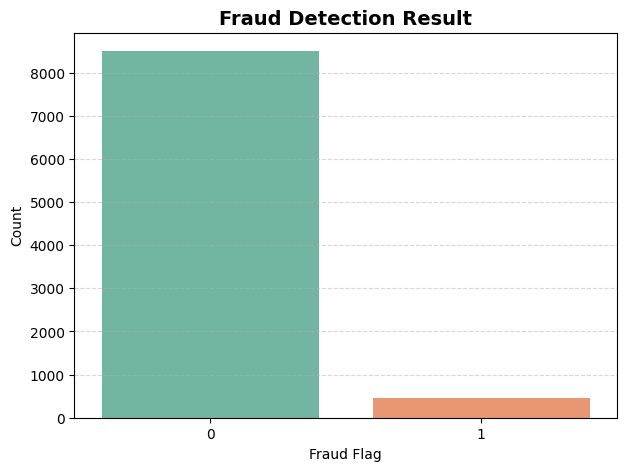

In [83]:
plt.figure(figsize=(7,5))
sns.countplot(x="Fraud_Flag", data=df, palette="Set2")

plt.title("Fraud Detection Result", fontsize=14, fontweight="bold")
plt.xlabel("Fraud Flag")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


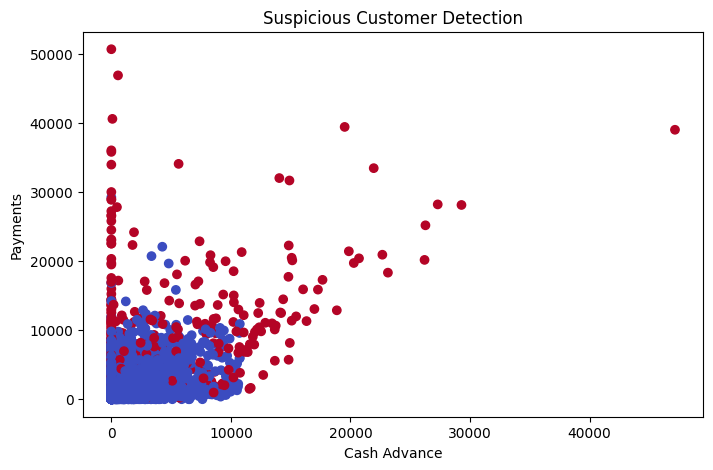

In [76]:


plt.figure(figsize=(8,5))
plt.scatter(
    df["CASH_ADVANCE"],
    df["PAYMENTS"],
    c=df["Fraud_Flag"],
    cmap="coolwarm"
)
plt.xlabel("Cash Advance")
plt.ylabel("Payments")
plt.title("Suspicious Customer Detection")
plt.show()


In [85]:
from google.colab import files
files.download('fraud_detection_output.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>